<a href="https://colab.research.google.com/github/MDRobiulhassan/Mental-Health/blob/main/Mental_Health_Treatment_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [493]:
import numpy as np
import pandas as pd

In [494]:
df=pd.read_csv("/content/drive/MyDrive/University/7th Semester/MLL/Project/Mental Health Dataset.csv")

In [495]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [496]:
df.shape

(292364, 17)

# Data Preprocessing

In [497]:
df.duplicated().sum()

np.int64(2313)

In [498]:
df = df.drop_duplicates()

In [499]:
df.duplicated().sum()

np.int64(0)

In [500]:
df.isna().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5193
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


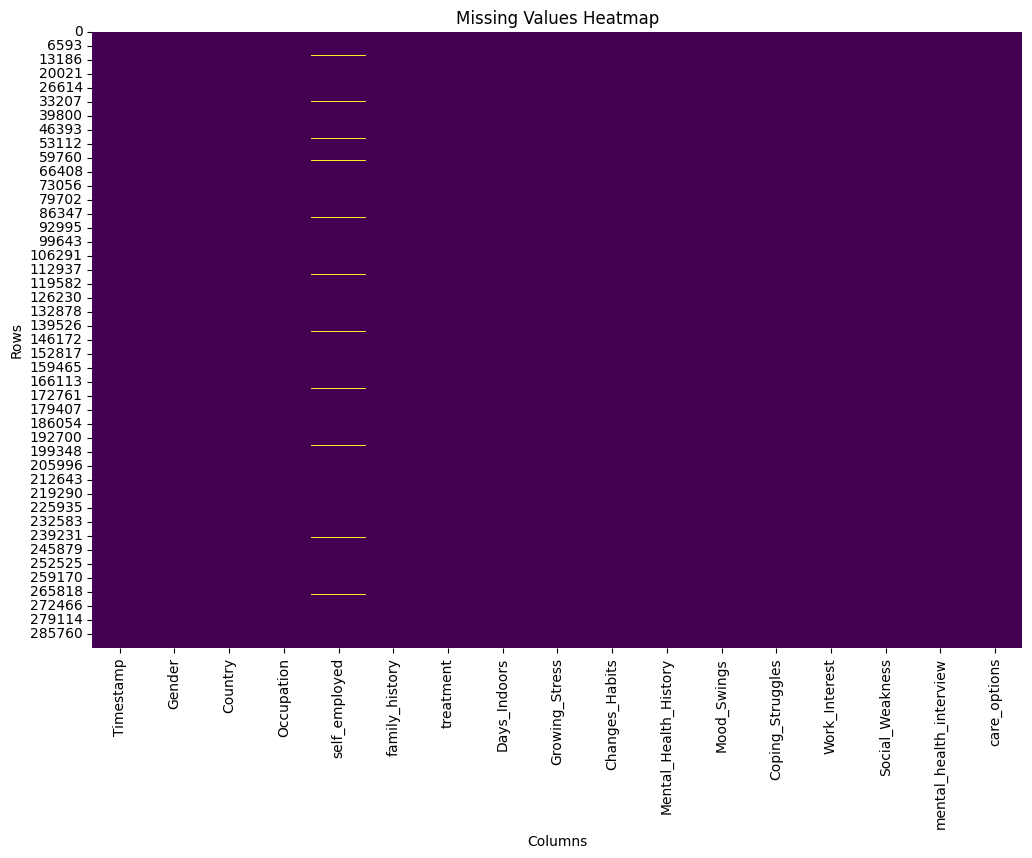

In [501]:
import matplotlib.pyplot as plt
import seaborn as sns

if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.xlabel('Columns')
    plt.ylabel('Rows')
    plt.show()
else:
    print("No missing values to display in the heatmap.")

In [502]:
mode_self_employed = df['self_employed'].mode()[0]
df['self_employed'] = df['self_employed'].fillna(mode_self_employed)

print(f"Missing values in 'self_employed' filled with: {mode_self_employed}")

Missing values in 'self_employed' filled with: No


In [503]:
df.isna().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,0
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [504]:
df = df.drop('Timestamp', axis=1)

## Encoding Categorical Features

In [505]:
df.dtypes

,0
Gender,object
Country,object
Occupation,object
self_employed,object
family_history,object
treatment,object
Days_Indoors,object
Growing_Stress,object
Changes_Habits,object
Mental_Health_History,object


In [506]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

display(df.head())

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,0,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


In [507]:
df.dtypes

,0
Gender,int64
Country,int64
Occupation,int64
self_employed,int64
family_history,int64
treatment,int64
Days_Indoors,int64
Growing_Stress,int64
Changes_Habits,int64
Mental_Health_History,int64


In [508]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,0,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


In [509]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290051 entries, 0 to 292363
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Gender                   290051 non-null  int64
 1   Country                  290051 non-null  int64
 2   Occupation               290051 non-null  int64
 3   self_employed            290051 non-null  int64
 4   family_history           290051 non-null  int64
 5   treatment                290051 non-null  int64
 6   Days_Indoors             290051 non-null  int64
 7   Growing_Stress           290051 non-null  int64
 8   Changes_Habits           290051 non-null  int64
 9   Mental_Health_History    290051 non-null  int64
 10  Mood_Swings              290051 non-null  int64
 11  Coping_Struggles         290051 non-null  int64
 12  Work_Interest            290051 non-null  int64
 13  Social_Weakness          290051 non-null  int64
 14  mental_health_interview  290051 non-null 

## Outlier Detection

In [510]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,290051.0,0.820201,0.384021,0.0,1.0,1.0,1.0,1.0
Country,290051.0,28.662570,10.213217,0.0,33.0,34.0,34.0,34.0
Occupation,290051.0,2.050301,1.385362,0.0,1.0,2.0,3.0,4.0
self_employed,290051.0,0.100489,0.300652,0.0,0.0,0.0,0.0,1.0
family_history,290051.0,0.394872,0.488824,0.0,0.0,0.0,1.0,1.0
treatment,290051.0,0.503994,0.499985,0.0,0.0,1.0,1.0,1.0
Days_Indoors,290051.0,1.962527,1.420416,0.0,1.0,2.0,3.0,4.0
Growing_Stress,290051.0,0.998176,0.826367,0.0,0.0,1.0,2.0,2.0
Changes_Habits,290051.0,1.049988,0.835252,0.0,0.0,1.0,2.0,2.0
Mental_Health_History,290051.0,0.992091,0.802341,0.0,0.0,1.0,2.0,2.0


In [511]:
outlier_info = {}

for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_info[column] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
    }

outlier_df = pd.DataFrame(outlier_info).T
display(outlier_df)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
Gender,1.0,1.0,0.0,1.0,1.0,52151.0
Country,33.0,34.0,1.0,31.5,35.5,69193.0
Occupation,1.0,3.0,2.0,-2.0,6.0,0.0
self_employed,0.0,0.0,0.0,0.0,0.0,29147.0
family_history,0.0,1.0,1.0,-1.5,2.5,0.0
treatment,0.0,1.0,1.0,-1.5,2.5,0.0
Days_Indoors,1.0,3.0,2.0,-2.0,6.0,0.0
Growing_Stress,0.0,2.0,2.0,-3.0,5.0,0.0
Changes_Habits,0.0,2.0,2.0,-3.0,5.0,0.0
Mental_Health_History,0.0,2.0,2.0,-3.0,5.0,0.0


In [512]:
columns_with_outliers = outlier_df[outlier_df['Outlier Count'] > 0].index.tolist()

if not columns_with_outliers:
    print("No outliers detected in any column based on the IQR method.")
else:
    print(f"Columns with outliers: {', '.join(columns_with_outliers)}")

Columns with outliers: Gender, Country, self_employed, mental_health_interview


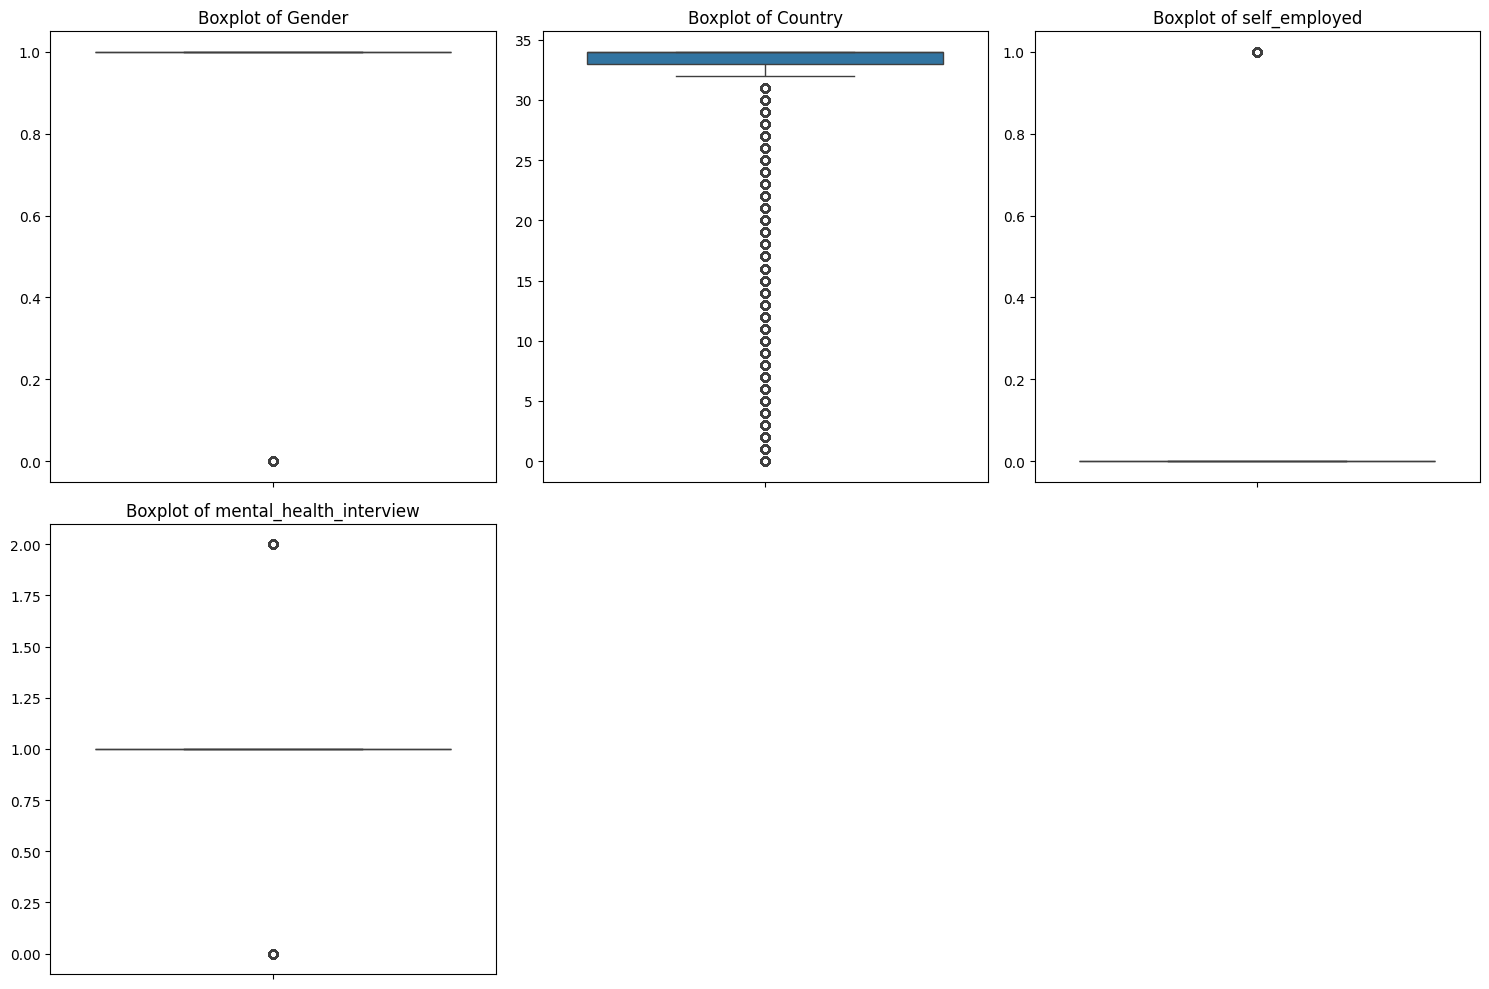

In [513]:
import matplotlib.pyplot as plt
import seaborn as sns

if columns_with_outliers:
    num_cols = len(columns_with_outliers)
    num_rows = (num_cols + 2) // 3
    plt.figure(figsize=(15, 5 * num_rows))

    for i, column in enumerate(columns_with_outliers):
        plt.subplot(num_rows, 3, i + 1)
        sns.boxplot(y=df[column])
        plt.title(f'Boxplot of {column}')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()
else:
    print("No outliers to plot.")

In [514]:
for col in df.columns:
    print(col, df[col].nunique())

Gender 2
Country 35
Occupation 5
self_employed 2
family_history 2
treatment 2
Days_Indoors 5
Growing_Stress 3
Changes_Habits 3
Mental_Health_History 3
Mood_Swings 3
Coping_Struggles 2
Work_Interest 3
Social_Weakness 3
mental_health_interview 3
care_options 3


In [515]:
print(df['Gender'].value_counts(normalize=True))
print(df['self_employed'].value_counts(normalize=True))
print(df['mental_health_interview'].value_counts(normalize=True))

Gender
1    0.820201
0    0.179799
Name: proportion, dtype: float64
self_employed
0    0.899511
1    0.100489
Name: proportion, dtype: float64
mental_health_interview
1    0.792581
0    0.177696
2    0.029722
Name: proportion, dtype: float64


In [516]:
print(df.shape)
print(df.head())
print(df.dtypes.unique())

(290051, 16)
   Gender  Country  Occupation  self_employed  family_history  treatment  \
0       0       34           1              0               0          1   
1       0       34           1              0               1          1   
2       0       34           1              0               1          1   
3       0       34           1              0               1          1   
4       0       34           1              0               1          1   

   Days_Indoors  Growing_Stress  Changes_Habits  Mental_Health_History  \
0             0               2               1                      2   
1             0               2               1                      2   
2             0               2               1                      2   
3             0               2               1                      2   
4             0               2               1                      2   

   Mood_Swings  Coping_Struggles  Work_Interest  Social_Weakness  \
0            2   

## Data Transformation

### Data aggregation

In [517]:
gender_treatment_agg = df.groupby('treatment')['Gender'].value_counts().unstack(fill_value=0)
display(gender_treatment_agg)

family_history_treatment_agg = df.groupby('treatment')['family_history'].value_counts().unstack(fill_value=0)
display(family_history_treatment_agg)

occupation_treatment_agg = df.groupby('treatment')['Occupation'].value_counts().unstack(fill_value=0)
display(occupation_treatment_agg)


Gender,0,1
treatment,,
0,15947,127920
1,36204,109980


family_history,0,1
treatment,,
0,112914,30953
1,62604,83580


Occupation,0,1,2,3,4
treatment,,,,,
0,24571,30581,32744,25777,30194
1,25248,30102,33162,26598,31074


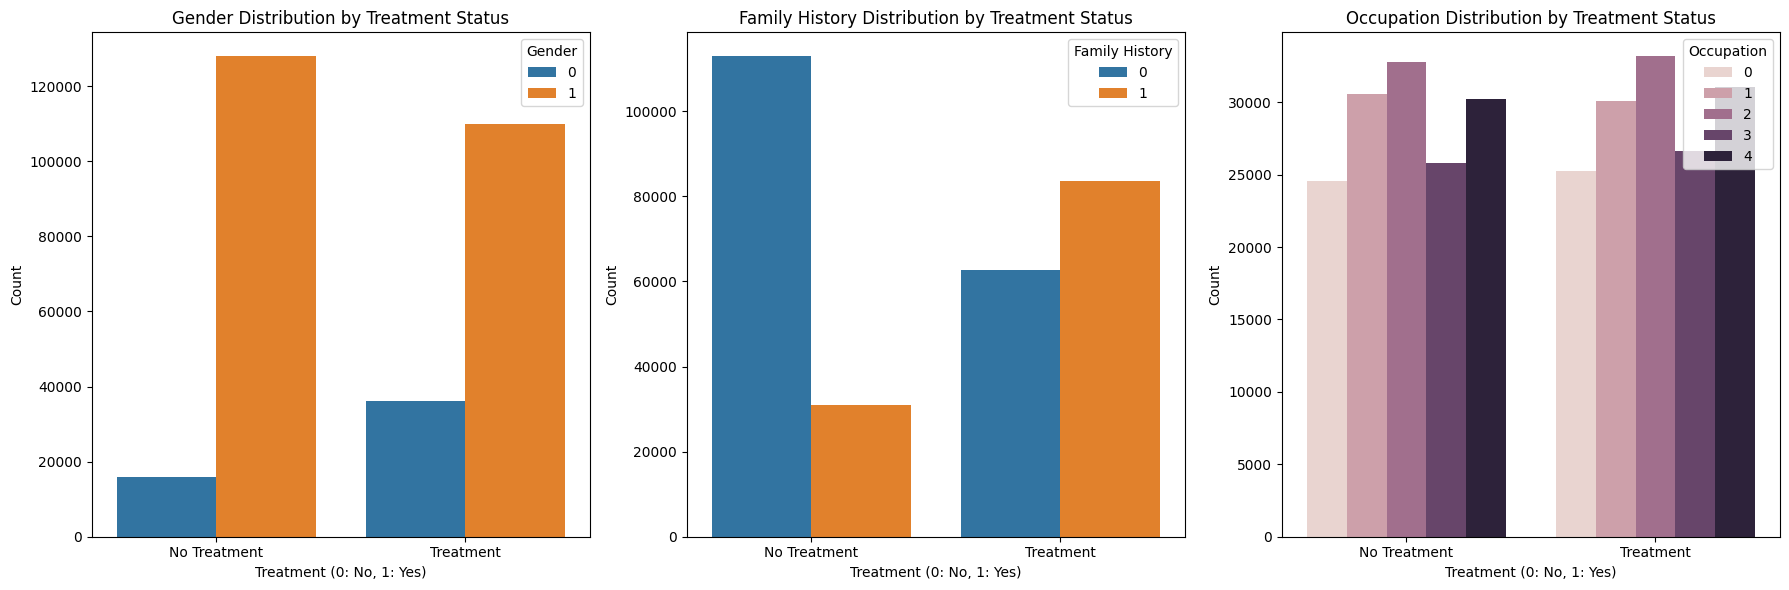

In [518]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6)) # Adjust figure size to accommodate three subplots

# Subplot 1: Gender vs. Treatment
plt.subplot(1, 3, 1) # 1 row, 3 columns, first subplot
sns.barplot(data=gender_treatment_agg.stack().reset_index(name='Count'), x='treatment', y='Count', hue='Gender')
plt.title('Gender Distribution by Treatment Status')
plt.xlabel('Treatment (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Treatment', 'Treatment'])
plt.legend(title='Gender', loc='upper right')

plt.subplot(1, 3, 2)
sns.barplot(data=family_history_treatment_agg.stack().reset_index(name='Count'), x='treatment', y='Count', hue='family_history')
plt.title('Family History Distribution by Treatment Status')
plt.xlabel('Treatment (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Treatment', 'Treatment'])
plt.legend(title='Family History', loc='upper right')

plt.subplot(1, 3, 3)
sns.barplot(data=occupation_treatment_agg.stack().reset_index(name='Count'), x='treatment', y='Count', hue='Occupation')
plt.title('Occupation Distribution by Treatment Status')
plt.xlabel('Treatment (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Treatment', 'Treatment'])
plt.legend(title='Occupation', loc='upper right')

plt.tight_layout()
plt.show()

# Feature Engineering

In [519]:
import sklearn.neighbors
import pandas as pd

In [520]:
feature_names = df.drop(columns=['treatment']).columns.tolist()

In [521]:

def get_knn(df, n, k, metric):

    # IMPORTANT: reset index to avoid mismatch
    df = df.reset_index(drop=True)

    X = df[feature_names]

    nbrs = sklearn.neighbors.NearestNeighbors(
        n_neighbors=k,
        metric=metric,
        algorithm='brute'
    )

    nbrs.fit(X)

    distances, indices = nbrs.kneighbors(
        X.iloc[[n]],
        return_distance=True
    )

    result = df.iloc[indices[0]].copy()
    result['distance'] = distances[0].reshape(-1)

    return result

In [522]:
get_knn(df, 1, 50, 'euclidean')

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,distance
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
60,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
66,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
70,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
78,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
33,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
96,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
99,0,34,1,0,1,0,0,2,1,2,2,0,1,2,1,0,0.000000
104,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.000000
107,0,34,1,0,1,0,0,2,1,2,2,0,1,2,1,0,0.000000


In [523]:
get_knn(df, 1, 50, 'manhattan')

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,distance
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
70,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
66,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
60,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
104,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
19,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
107,0,34,1,0,1,0,0,2,1,2,2,0,1,2,1,0,0.0
96,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
120,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0
112,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,0.0


In [524]:
transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())
df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

/tmp/ipykernel_2555/799851277.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
/tmp/ipykernel_2555/799851277.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.25 0.25 0.25 ... 0.   0.   0.  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
/tmp/ipykernel_2555/799851277.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.   0.   0.   ... 0.25 0.25 0.25]' has dtype incompatible with int64, please explicitly cast to a compatible dtype f

In [525]:
get_knn(df_scaled, 1, 10, 'euclidean')

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,distance
70,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
60,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
78,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
1,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
99,0,1.0,0.25,0,1,0,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
66,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
19,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
104,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
96,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
33,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0


In [526]:
get_knn(df_scaled, 1, 10, 'manhattan')

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,distance
70,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
60,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
78,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
1,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
99,0,1.0,0.25,0,1,0,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
66,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
19,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
104,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
96,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0
33,0,1.0,0.25,0,1,1,0.0,1.0,0.5,1.0,1.0,0,0.5,1.0,0.5,0.0,0.0


## Normalization

In [527]:
from sklearn.model_selection import train_test_split

X = df.drop('treatment', axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [528]:
from sklearn.preprocessing import MinMaxScaler

std = MinMaxScaler().fit(X_train)

X_train_std = std.transform(X_train)

X_test_std = std.transform(X_test)

## Standardization

In [529]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [530]:
beforeScaling_lr = LogisticRegression(random_state = 42)

In [531]:
beforeScaling_lr.fit(X_train_std, y_train)
y_predict_test_lr = beforeScaling_lr.predict(X_test_std)
y_probability_test_lr = beforeScaling_lr.predict_proba(X_test_std)[:, 1]
print('F1 score =', f1_score(y_test, y_predict_test_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_test_lr))

F1 score = 0.7085779654458894
AUC-ROC score = 0.7550493516173667


In [532]:
scaler = StandardScaler()

In [533]:
X_train_ss = scaler.fit_transform(X_train)
X_test_ss = scaler.transform(X_test)

In [534]:
ss_lr = LogisticRegression(random_state = 42)
ss_lr.fit(X_train_ss, y_train)

y_predict_test_ss_lr = ss_lr.predict(X_test_ss)
y_probability_test_ss_lr = ss_lr.predict_proba(X_test_ss)[:, 1]

print('F1 score (StandardScaler) =', f1_score(y_test, y_predict_test_ss_lr))
print('AUC-ROC score (StandardScaler) =', roc_auc_score(y_test, y_probability_test_ss_lr))

F1 score (StandardScaler) = 0.7085127860026917
AUC-ROC score (StandardScaler) = 0.7550773808206774


In [535]:
afterScaling_lr = LogisticRegression(random_state = 42)

In [536]:
afterScaling_lr.fit(X_train_ss, y_train)
y_predict_valid_lr = afterScaling_lr.predict(X_test_ss)
y_probability_valid_lr = afterScaling_lr.predict_proba(X_test_ss)[:, 1]
print('F1 score =', f1_score(y_test, y_predict_valid_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr))

F1 score = 0.7085127860026917
AUC-ROC score = 0.7550773808206774
